In [1]:
import os
import seaborn as sns
from LingerGRN import Benchmk
import matplotlib.colors as mcolors

In [2]:
def generate_colors(N):
    """
    Generate N visually appealing colors using seaborn color palette.
    
    Args:
        N (int): The number of colors to generate.
    
    Returns:
        list: A list of N RGB tuples representing the generated colors.
    """
    color_palette = sns.color_palette("husl", N)
    colors = [mcolors.rgb2hex(color_palette[i]) for i in range(N)]
    return colors

def bm_trans(TFName,Method_name,Groundtruth,Infer_trans,outdir,filetype, N=500):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, roc_auc_score
    import seaborn as sns
    # Set the working directory
    # Use the appropriate path for your system
    import os
    data0=pd.read_csv(Groundtruth,sep='\t', skiprows=5,header=0)
    data1=data0.groupby(['symbol'])['score'].max()
    #print(f"data1: {data1}")
    label=data1.sort_values(axis=0, ascending=False)
    label=label.reset_index()
    N = N # top 500 TG as the ground truth
    label = label['symbol'].iloc[:N]
    #print(f"label: {label}")
    # Load data
    colors=generate_colors(len(Infer_trans))
    for i in range(len(Infer_trans)):
        if filetype=='list':
            data2 = pd.read_csv(Infer_trans[i], sep='\t')
        #label = pd.read_csv('~/SC_NET/all_data/result/LL_sc/max/' + info0['id'][i] + '_gene_score_5fold.txt', header=True)
            loc = data2[data2['TF'] == TFName].index
            TGName = data2['TG'].values[loc].tolist()
            TGset = TGName.copy()
            Score = data2['score'].values[loc]
        if filetype=='matrix':
            data2=pd.read_csv(Infer_trans[i], sep='\t',header=0,index_col=0)
            TGset=data2.index
            Score=data2[TFName].values

            print(Infer_trans[i])
            print(len(TGset))
            print(len(Score))
        d1 = np.zeros(len(TGset))
        #print(d1)
        loc = np.where(np.isin(TGset, label))[0]
        #print(loc)
        d1[loc] = 1
        fpr, tpr, thresholds = roc_curve(d1, Score)
        # Compute AUC
        auc = roc_auc_score(d1, Score)
        print(f"auc: {auc}")
        # Plot the ROC curve
        plt.plot(fpr, tpr, color=colors[i], label=Method_name[i]+': (AUC = %0.2f)' % auc)
        plt.plot([0, 1], [0, 1], color='black', linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
    # Display the plot in the notebook
    plt.savefig(outdir+"trans_roc_curve"+TFName+".png", format='png', bbox_inches='tight')
    plt.show()
    plt.close()
    from sklearn.metrics import precision_recall_curve
    from sklearn.metrics import average_precision_score
    for i in range(len(Infer_trans)):
        if filetype=='list':
            data2 = pd.read_csv(Infer_trans[i], sep='\t')
            #label = pd.read_csv('~/SC_NET/all_data/result/LL_sc/max/' + info0['id'][i] + '_gene_score_5fold.txt', header=True)
            loc = data2[data2['TF'] == TFName].index
            TGName = data2['TG'].values[loc].tolist()
            TGset = TGName.copy()
            Score = data2['score'].values[loc]
        if filetype=='matrix':
            data2=pd.read_csv(Infer_trans[i], sep='\t',header=0,index_col=0)
            TGset=data2.index
            Score=data2[TFName].values
        d1 = np.zeros(len(TGset))
        loc = np.where(np.isin(TGset, label))[0]
        d1[loc] = 1
        # Assuming you have the true labels (y_true) and predicted probabilities (y_scores) for your classifier
        # Calculate the average precision score (AUPR
        aupr = average_precision_score(d1, Score)
        auprr=aupr*len(d1)/sum(d1)
        # Assuming you have the true labels (y_true) and predicted probabilities (y_scores) for your classifier
        # Calculate precision and recall values
        precision, recall, _ = precision_recall_curve(d1, Score)
        print(f"aupr: {aupr}")
        print(f"auprr: {auprr}")
        # Plot precision-recall curve
        plt.plot(recall, precision, color=colors[i], label=Method_name[i]+': (AUPR ratio = %0.2f)' % auprr)
        plt.ylim([0.0, 0.6])
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve')
        plt.legend(loc='upper right')
    plt.savefig(outdir+"trans_pr_curve"+TFName+".png", format='png', bbox_inches='tight')
    plt.show()
    plt.close()

In [10]:
data_path = 'output_compare_2026-02-20'
N = 500

In [11]:
CASE = "case1"
cases__list = []
sub_cases__list = []
Method_name = []
Infer_trans = [] 

Method_name.append('LINGER')
Infer_trans.append('/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/LINGER/compare/cell_type_specific_trans_regulatory_naive B cells_case1.txt')

#Method_name.append('scPRINT')
#Infer_trans.append('/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/output_compare_2026-02-17/scprint_grn_case1.txt')

Method_name.append('GRNBoost2')
Infer_trans.append('/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/output_compare_2026-02-25/GRNBoost2_grn_case1.txt')

for root, dirs, files in os.walk(data_path):
    for f in files:
        if f.lower().endswith(".txt"):
            if "scprint" not in f and f.split("_")[3] == CASE:
                print(f)
                print(f.split("_")[3])
                print(f.split("_")[4][:-4])

                Method_name.append("NetMap_"+f.split("_")[4][:-4])
                Infer_trans.append(os.path.join(data_path, f))
                #sub_cases__list.append(f.split("_")[4][:-4])

print(Method_name)
print(Infer_trans)

source_target_matrix_case1_noD.txt
case1
noD
source_target_matrix_case1_noD(Abs).txt
case1
noD(Abs)
source_target_matrix_case1_D.txt
case1
D
source_target_matrix_case1_D(Abs).txt
case1
D(Abs)
['LINGER', 'GRNBoost2', 'NetMap_noD', 'NetMap_noD(Abs)', 'NetMap_D', 'NetMap_D(Abs)']
['/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/LINGER/compare/cell_type_specific_trans_regulatory_naive B cells_case1.txt', '/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/output_compare_2026-02-25/GRNBoost2_grn_case1.txt', 'output_compare_2026-02-20/source_target_matrix_case1_noD.txt', 'output_compare_2026-02-20/source_target_matrix_case1_noD(Abs).txt', 'output_compare_2026-02-20/source_target_matrix_case1_D.txt', 'output_compare_2026-02-20/source_target_matrix_case1_D(Abs).txt']


/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/LINGER/compare/cell_type_specific_trans_regulatory_naive B cells_case1.txt
1021
1021
auc: 0.7569523809523809
/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/output_compare_2026-02-25/GRNBoost2_grn_case1.txt
1085
1085
auc: 0.5591481828595231
output_compare_2026-02-20/source_target_matrix_case1_noD.txt
1500
1500
auc: 0.6030136192407998
output_compare_2026-02-20/source_target_matrix_case1_noD(Abs).txt
1500
1500
auc: 0.5449145175311504
output_compare_2026-02-20/source_target_matrix_case1_D.txt
1420
1420
auc: 0.5613471580450055
output_compare_2026-02-20/source_target_matrix_case1_D(Abs).txt
1420
1420
auc: 0.5149892933618843


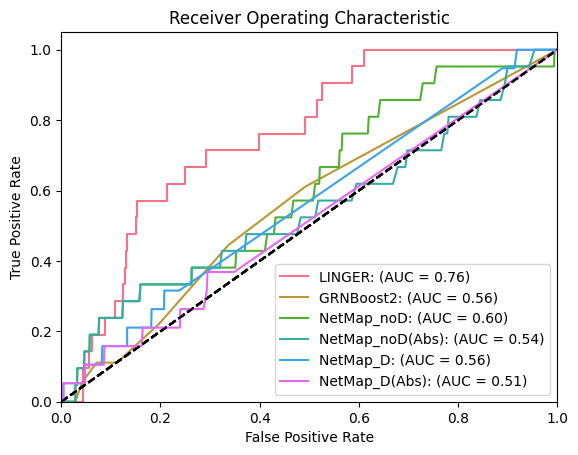

aupr: 0.049395710613889886
auprr: 2.4015724065134085
aupr: 0.01941550640716788
auprr: 1.170323580654286
aupr: 0.023650235990768157
auprr: 1.689302570769154
aupr: 0.022305447582461724
auprr: 1.5932462558901233
aupr: 0.02331434052608598
auprr: 1.7424401866864259
aupr: 0.022064103155408795
auprr: 1.6490013937200256


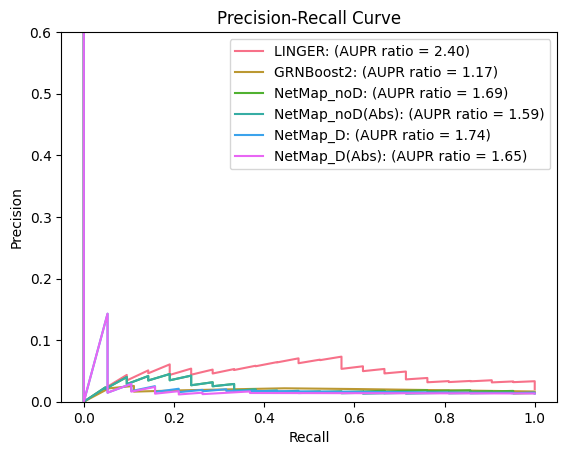

In [12]:
outdir = data_path
TFName = 'IRF4'
Method_name= Method_name
Infer_trans= Infer_trans
Groundtruth="/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/LINGER/compare/40215_gene_score_5fold.txt"

#for N in [250, 500]:
bm_trans(TFName,Method_name,Groundtruth,Infer_trans,outdir,'matrix', N=N)

In [13]:
CASE = "case2"
cases__list = []
sub_cases__list = []
Method_name = []
Infer_trans = [] 

Method_name.append('LINGER')
Infer_trans.append('/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/LINGER/compare/cell_type_specific_trans_regulatory_classical monocytes_case2.txt')

Method_name.append('scPRINT')
Infer_trans.append('/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/scPRINT/output_compare_2026-02-25/scprint_grn_case2.txt')

Method_name.append('GRNBoost2')
Infer_trans.append('/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/output_compare_2026-02-25/GRNBoost2_grn_case2.txt')



for root, dirs, files in os.walk(data_path):
    for f in files:
        if f.lower().endswith(".txt"):
            if "scprint" not in f and f.split("_")[3] == CASE:
                print(f)
                print(f.split("_")[3])
                print(f.split("_")[4][:-4])

                Method_name.append("NetMap_"+f.split("_")[4][:-4])
                Infer_trans.append(os.path.join(data_path, f))
                #sub_cases__list.append(f.split("_")[4][:-4])

print(Method_name)
print(Infer_trans)

source_target_matrix_case2_noD.txt
case2
noD
source_target_matrix_case2_noD(Abs).txt
case2
noD(Abs)
source_target_matrix_case2_D.txt
case2
D
source_target_matrix_case2_D(Abs).txt
case2
D(Abs)
['LINGER', 'scPRINT', 'GRNBoost2', 'NetMap_noD', 'NetMap_noD(Abs)', 'NetMap_D', 'NetMap_D(Abs)']
['/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/LINGER/compare/cell_type_specific_trans_regulatory_classical monocytes_case2.txt', '/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/scPRINT/output_compare_2026-02-25/scprint_grn_case2.txt', '/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/output_compare_2026-02-25/GRNBoost2_grn_case2.txt', 'output_compare_2026-02-20/source_target_matrix_case2_noD.txt', 'output_compare_2026-02-20/source_target_matrix_case2_noD(Abs).txt', 'output_compare_2026-02-20/source_target_matrix_case2_D.txt', 'output_compare_2026-02-20/source_target_matrix_case2_D(Abs).txt']


500
/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/LINGER/compare/cell_type_specific_trans_regulatory_classical monocytes_case2.txt
1021
1021
auc: 0.7094729733239824
/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/scPRINT/output_compare_2026-02-25/scprint_grn_case2.txt
1500
1500
auc: 0.56153501729249
/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/output_compare_2026-02-25/GRNBoost2_grn_case2.txt
1396
1396
auc: 0.5051588033332455
output_compare_2026-02-20/source_target_matrix_case2_noD.txt
1500
1500
auc: 0.6377518993046614
output_compare_2026-02-20/source_target_matrix_case2_noD(Abs).txt
1500
1500
auc: 0.6118577774916303
output_compare_2026-02-20/source_target_matrix_case2_D.txt
1498
1498
auc: 0.6268697614442295
output_compare_2026-02-20/source_target_matrix_case2_D(Abs).txt
1498
1498
auc: 0.6243391360412636


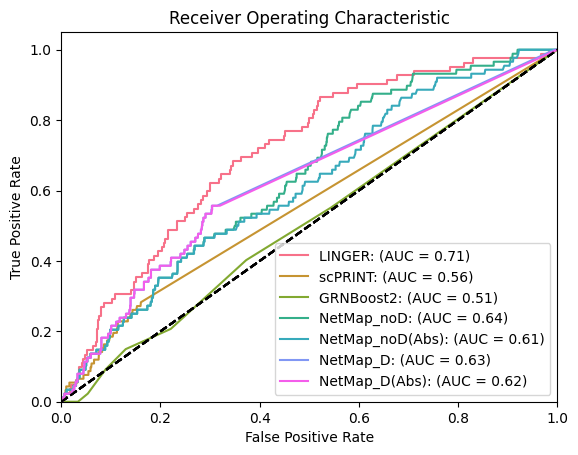

aupr: 0.1552760594867286
auprr: 1.9333763016579255
aupr: 0.08738633287609965
auprr: 1.4247771664581463
aupr: 0.06295565651049705
auprr: 1.010185017110964
aupr: 0.0925365117069999
auprr: 1.5773269040965894
aupr: 0.08949882143534499
auprr: 1.525548092647926
aupr: 0.0894784021877614
auprr: 1.5231664372416658
aupr: 0.08933376392509237
auprr: 1.5207042995430498


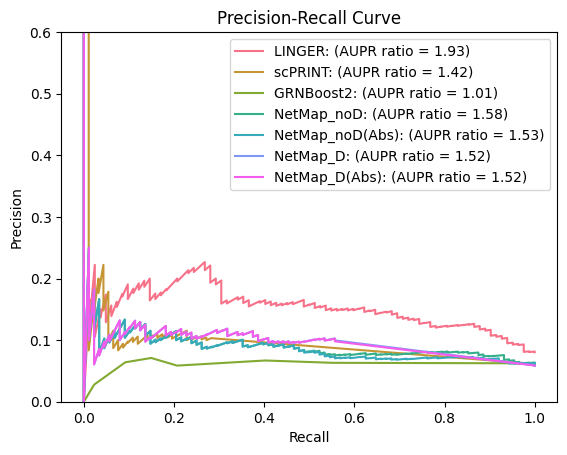

In [14]:
TFName = 'SPI1'
Method_name= Method_name
Infer_trans= Infer_trans

Groundtruth="/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/LINGER/compare/85986_gene_score_5fold.txt"

print(N)
bm_trans(TFName,Method_name,Groundtruth,Infer_trans,outdir,'matrix', N=N)

In [15]:
CASE = "case3"
cases__list = []
sub_cases__list = []
Method_name = []
Infer_trans = [] 

Method_name.append('LINGER')
Infer_trans.append('/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/LINGER/compare/cell_type_specific_trans_regulatory_naive CD4 T cells_case3.txt')

Method_name.append('scPRINT')
Infer_trans.append('/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/scPRINT/output_compare_2026-02-25/scprint_grn_case3.txt')

Method_name.append('GRNBoost2')
Infer_trans.append('/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/output_compare_2026-02-25/GRNBoost2_grn_case3.txt')


for root, dirs, files in os.walk(data_path):
    for f in files:
        if f.lower().endswith(".txt"):
            if "scprint" not in f and f.split("_")[3] == CASE:
                print(f)
                print(f.split("_")[3])
                print(f.split("_")[4][:-4])

                Method_name.append("NetMap_"+f.split("_")[4][:-4])
                Infer_trans.append(os.path.join(data_path, f))
                #sub_cases__list.append(f.split("_")[4][:-4])

print(Method_name)
print(Infer_trans)

source_target_matrix_case3_noD.txt
case3
noD
source_target_matrix_case3_noD(Abs).txt
case3
noD(Abs)
source_target_matrix_case3_D.txt
case3
D
source_target_matrix_case3_D(Abs).txt
case3
D(Abs)
['LINGER', 'scPRINT', 'GRNBoost2', 'NetMap_noD', 'NetMap_noD(Abs)', 'NetMap_D', 'NetMap_D(Abs)']
['/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/LINGER/compare/cell_type_specific_trans_regulatory_naive CD4 T cells_case3.txt', '/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/scPRINT/output_compare_2026-02-25/scprint_grn_case3.txt', '/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/output_compare_2026-02-25/GRNBoost2_grn_case3.txt', 'output_compare_2026-02-20/source_target_matrix_case3_noD.txt', 'output_compare_2026-02-20/source_target_matrix_case3_noD(Abs).txt', 'output_compare_2026-02-20/source_target_matrix_case3_D.txt', 'output_compare_2026-02-20/source_target_matrix_case3_D(Abs).txt']


500
/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/LINGER/compare/cell_type_specific_trans_regulatory_naive CD4 T cells_case3.txt
1488
1488
auc: 0.7035680109364321
/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/scPRINT/output_compare_2026-02-25/scprint_grn_case3.txt
1500
1500
auc: 0.5271219350973952
/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/Final_package/LINGER/output_compare_2026-02-25/GRNBoost2_grn_case3.txt
1940
1940
auc: 0.5843342036553525
output_compare_2026-02-20/source_target_matrix_case3_noD.txt
2000
2000
auc: 0.738379746835443
output_compare_2026-02-20/source_target_matrix_case3_noD(Abs).txt
2000
2000
auc: 0.7338025316455696
output_compare_2026-02-20/source_target_matrix_case3_D.txt
1977
1977
auc: 0.42258196721311475
output_compare_2026-02-20/source_target_matrix_case3_D(Abs).txt
1977
1977
auc: 0.41975409836065575


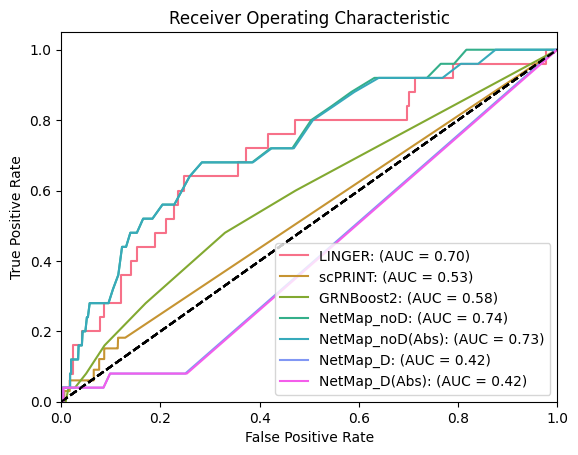

aupr: 0.06159806465824172
auprr: 3.666316808458547
aupr: 0.02743095180294762
auprr: 1.246861445588528
aupr: 0.017427373416124447
auprr: 1.3523641770912571
aupr: 0.04120664308837065
auprr: 3.2965314470696523
aupr: 0.04109690088373541
auprr: 3.287752070698833
aupr: 0.016526019028490428
auprr: 1.3068775847730232
aupr: 0.016490604147003252
auprr: 1.304076975945017


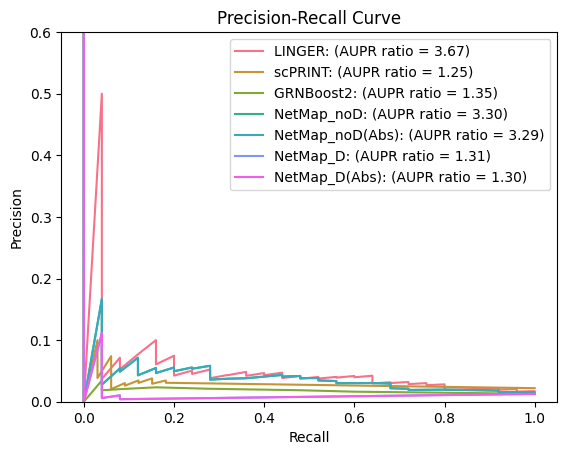

In [16]:
TFName = 'FOXP3'
Method_name= Method_name
Infer_trans= Infer_trans
Groundtruth="/home/baz8031/NetMap/2025/Evaluation/Final/netmap/tutorials/LINGER/compare/44098_gene_score_5fold.txt"


print(N)
bm_trans(TFName,Method_name,Groundtruth,Infer_trans,outdir,'matrix', N=N)